# Trening Multimodalnego Silnika Wyszukiwania (CLIP / Two-Tower)

Niniejszy notatnik dokumentuje proces budowy i treningu multimodalnego modelu uczenia maszynowego (Image-to-Text), służącego do wyszukiwania semantycznego. 

Projekt stanowi etap badawczy (Feature Extraction i Fine-Tuning) przed wdrożeniem modelu do środowiska produkcyjnego w architekturze mikroserwisowej (FastAPI + Baza Wektorowa).

**Główne założenia architektury:**
* **Wieża Wizyjna:** Pre-trenowany `EfficientNet-B0` (ekstrakcja cech przestrzennych, zamrożone wagi bazowe).
* **Wieża Tekstowa:** Pre-trenowany `DistilBERT` ze strategią Mean Pooling i obsługą maski uwagi (Attention Mask).
* **Funkcja straty:** Contrastive Loss (InfoNCE) z uczonym parametrem temperatury.
* **Optymalizacja batcha:** Autorski `HardNegativeBatchSampler` grupujący próbki klasami w celu redukcji zjawiska fałszywych negatywów.

In [71]:
# Ukrycie ostrzezen 
import warnings
warnings.filterwarnings("ignore")
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# importowaniem bibliotek PyTorch i Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Sampler
from torchvision import models
from torchvision.transforms import v2
from transformers import AutoTokenizer, AutoModel

#Biblioteki narzędziowe
import os
import json
import yaml
import random
import faiss
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

#Ustawienie seed'a dla gwarancji powtarzalności wyników eksperymentów
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

# Wczytanie pliku YAML ze zmiennymi 
with open("../configs/config_model_training.yaml", "r") as f:
    cfg = yaml.safe_load(f)

#Przypisanie najwaniejszych zmiennych

IMAGES_PATH = cfg['data']['images_path']
CAPTIONS_PATH = cfg['data']['captions_path']



## 2. Eksploracja Zbioru Danych (EDA)

In [58]:
dataset_dir = Path(IMAGES_PATH)
valid_extensions = {".jpg", ".jpeg", ".png"}

images_path = []
all_classes = []

for file_path in dataset_dir.rglob("*"):
    if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
        images_path.append(str(file_path))
        all_classes.append(file_path.parent.name)

unique_classes = sorted(set(all_classes))

print(f"Liczba poprawnych zdjęć: {len(images_path)}")
print(f"Liczba wykrytych klas: {len(unique_classes)}")

Liczba poprawnych zdjęć: 5400
Liczba wykrytych klas: 90


## Wczytanie podpisów oraz Wizualizacja

Liczba wczytanych podpisów: 5400


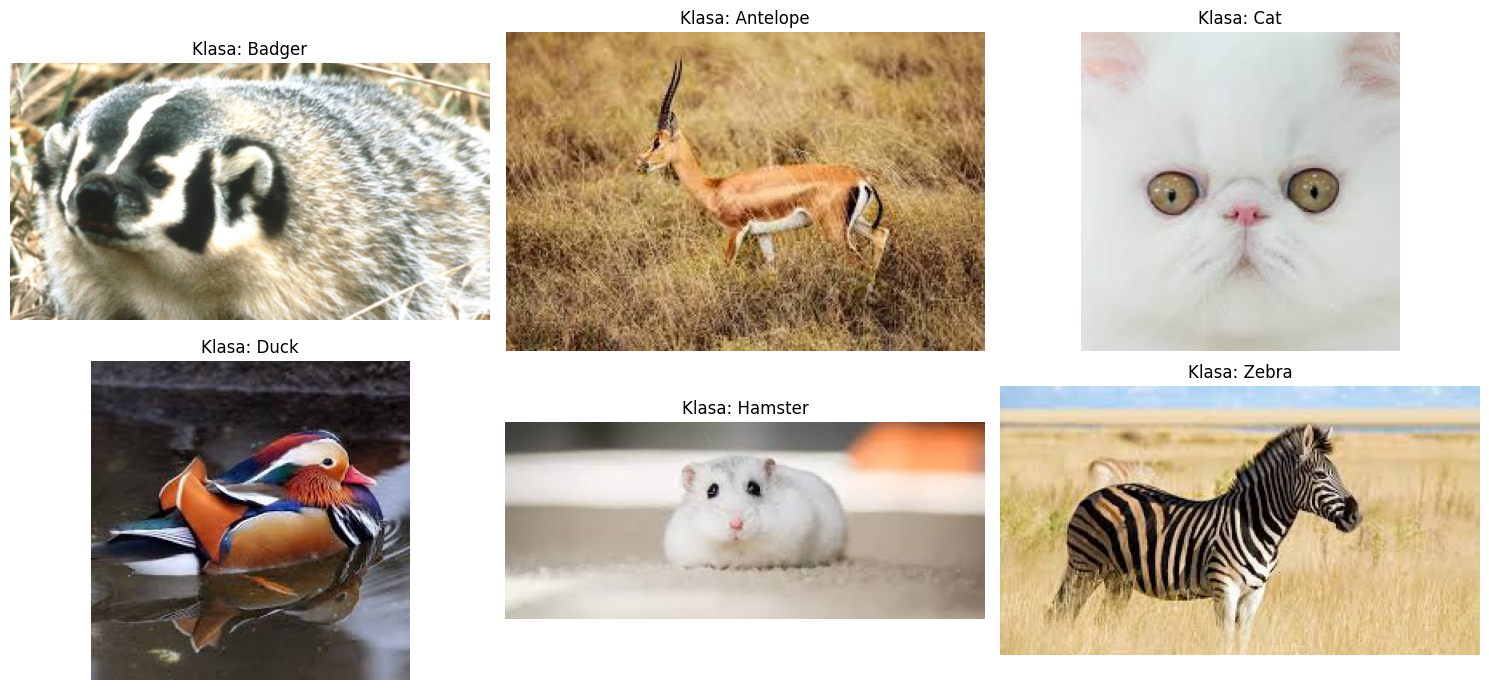

In [59]:
with open(CAPTIONS_PATH, "r", encoding="utf-8") as file:
    captions = json.load(file)

print(f"Liczba wczytanych podpisów: {len(captions)}")

sample_paths = random.sample(images_path, 6)

plt.figure(figsize=(15, 7))
for i, path_str in enumerate(sample_paths):
    image_path = Path(path_str)
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)

    plt.title(f"Klasa: {image_path.parent.name.capitalize()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Dataset i Pipeline Danych

In [60]:
captions_dict = {Path(item['path']).name: item['caption'] for item in captions}

class CLIPDataset(Dataset):
    def __init__(self, all_images_paths, captions_dict, tokenizer, max_text_length, transform=None):
        self.images_paths = all_images_paths
        self.captions = captions_dict
        self.tokenizer = tokenizer
        self.max_text_length = max_text_length
        self.targets = [Path(path).parent.name for path in self.images_paths]

        if transform is not None:
            self.transform = transform
        else:
            self.transform = v2.Compose([
                v2.Resize(256),
                v2.CenterCrop(224),
                v2.RandomHorizontalFlip(),
                v2.RandomRotation(degrees=20),
                v2.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2,
                    hue=0.1
                ),
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, index):
        image_path = self.images_paths[index]
        img = Image.open(image_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        file_name = Path(image_path).name
        text = str(self.captions[file_name])

        tokens = self.tokenizer(
            text,
            max_length=self.max_text_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        input_ids = tokens['input_ids'].squeeze(0)
        attention_mask = tokens['attention_mask'].squeeze(0)

        return img, input_ids, attention_mask

tokenizer = AutoTokenizer.from_pretrained(cfg['model']['text_encoder'])
dataset = CLIPDataset(
    all_images_paths=images_path,
    captions_dict=captions_dict,
    tokenizer=tokenizer,
    max_text_length=cfg['model']['max_text_length']
)

In [61]:
class ImageEmbeddingTower(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.num_dims = num_dims

        model_weights = models.EfficientNet_B0_Weights.DEFAULT
        self.backbone = models.efficientnet_b0(weights=model_weights)

        for params in self.backbone.parameters():
            params.requires_grad = False

        self.num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()


        self.embedding_head = nn.Sequential(
            nn.Linear(self.num_features, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.embedding_head(features)

class TextEmbeddingTower(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.num_dims = num_dims

        self.text_encoder_model = AutoModel.from_pretrained("distilbert-base-uncased", attn_implementation="eager")
        self.num_bert_feature = self.text_encoder_model.config.hidden_size

        for params in self.text_encoder_model.parameters():
            params.requires_grad = False

        self.text_projection = nn.Sequential(
            nn.Linear(self.num_bert_feature, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def mean_pooling(self, last_hidden_state, attention_mask):

        input_mask_expanded = (
            attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        )

        sum_embedding = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embedding / sum_mask

    def forward(self, input_ids, attention_mask):
        text_outputs = self.text_encoder_model(input_ids, attention_mask)
        pooled_output = self.mean_pooling(last_hidden_state=text_outputs.last_hidden_state, attention_mask=attention_mask)

        projected_embd = self.text_projection(pooled_output)

        return projected_embd

class CLIPModel(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.image_tower = ImageEmbeddingTower(num_dims)
        self.text_tower = TextEmbeddingTower(num_dims)

    def forward(self, x, input_ids, attention_mask):
        image_embedding = self.image_tower(x)
        text_embedding = self.text_tower(input_ids, attention_mask)

        img_norm = F.normalize(image_embedding, p=2, dim=-1)
        text_norm = F.normalize(text_embedding, p=2, dim=-1)
        return img_norm, text_norm
    


class ClipLoss(nn.Module):
    def __init__(self, init_temp=0.07):
        super().__init__()
        self.loss = nn.CrossEntropyLoss()
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / init_temp))

    def forward(self, img_emb, text_emb):

        logit_scale = torch.clamp(self.logit_scale.exp(), max=100)
        logits = logit_scale * (img_emb @ text_emb.T)

        batch_size = img_emb.shape[0]
        targets = torch.arange(batch_size, device=img_emb.device)

        loss_img = self.loss(logits, targets)
        loss_text = self.loss(logits.T, targets)

        return (loss_img + loss_text) / 2



criterion = ClipLoss()
model = CLIPModel(cfg['model']['embedding_dim'])

optimizer = torch.optim.AdamW([
    {"params": model.parameters()},
    {"params": criterion.parameters()}
], lr=cfg['training']['learning_rate_head'])

device = cfg['training']['device']
model.to(device)
criterion.to(device)

        

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7101.77it/s]


ClipLoss(
  (loss): CrossEntropyLoss()
)

## 4. Implementacja autorskiego samplera

In [62]:
class HardNegativeBatchSampler(Sampler):
    def __init__(self, labels, batch_size, samples_per_class):
        self.labels = labels
        self.batch_size = batch_size
        self.samples_per_class = samples_per_class

        self.classes_per_batch = batch_size // samples_per_class

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(labels):
            self.class_to_indices[label].append(idx)

        self.classes = list(self.class_to_indices.keys())
        self.num_batches = len(labels) // batch_size

    def __iter__(self):
        for _ in range(self.num_batches):
            batch_indices = []
            selected_classes = random.sample(self.classes, self.classes_per_batch)

            for cls in selected_classes:
                indices = self.class_to_indices[cls]
                if len(indices) >= self.samples_per_class:
                    sampled = random.sample(indices, self.samples_per_class)
                else:
                    sampled = random.choices(indices, k=self.samples_per_class)

                batch_indices.extend(sampled)

            random.shuffle(batch_indices)

            yield batch_indices

    def __len__(self):
        return self.num_batches

In [63]:
all_labels = dataset.targets

custom_sampler = HardNegativeBatchSampler(
    labels=all_labels,
    batch_size=cfg['training']['batch_size'],
    samples_per_class=cfg['training']['samples_per_class']
)

dataloader = DataLoader(
    dataset,
    batch_sampler=custom_sampler,
    num_workers=0
)

## 5. Pętla treningowa z metrykami


In [64]:
def train_epoch(model, criterion, optimizer, loader, device):
    model.train()

    model.image_tower.backbone.features[:-2].eval()

    total_loss, total_i2t_top1, total_i2t_top3 = 0.0, 0.0, 0.0

    progress_bar = tqdm(loader, desc="Training Epoch: ")

    for image, input_ids, attention_mask in progress_bar:
        image = image.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        optimizer.zero_grad()

        img_emb, text_emb = model(image, input_ids, attention_mask)
        loss = criterion(img_emb, text_emb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            logit_scale = torch.clamp(criterion.logit_scale.exp(), max=100)
            logit_per_image = logit_scale * (img_emb @ text_emb.T)

            targets = torch.arange(image.shape[0], device=device)
            i2t_acc_top1 = (logit_per_image.argmax(dim=1) == targets).float().mean().item()

            k = min(3, image.shape[0])
            _, top3_indices = logit_per_image.topk(k, dim=1)
            i2t_acc_top3 = (top3_indices == targets.unsqueeze(1)).any(dim=1).float().mean().item()

        total_loss += loss.item()
        total_i2t_top1 += i2t_acc_top1
        total_i2t_top3 += i2t_acc_top3

        progress_bar.set_postfix({
            'Loss': f"{loss.item():.4f}", 
            'Top1': f"{i2t_acc_top1:.2f}",
            'Top3': f"{i2t_acc_top3:.2f}"
        })

        epoch_metrics = {
                "loss": total_loss / len(loader),
                "top1_accuracy": total_i2t_top1 / len(loader),
                "top3_accuracy": total_i2t_top3 / len(loader)
            }

    return epoch_metrics

In [65]:
epochs = cfg['training']['epochs']
best_loss = float('inf')

for epoch in range(epochs):
    metrics = train_epoch(model, criterion, optimizer, dataloader, device)

    epoch_loss = metrics['loss']
    top1 = metrics['top1_accuracy']
    top3 = metrics['top3_accuracy']

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f} | Top-1: {top1:.2%} | Top-3: {top3:.2%}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "../models/best_model.pth")


Training Epoch: 100%|██████████| 168/168 [00:50<00:00,  3.35it/s, Loss=1.5183, Top1=0.59, Top3=0.84]


Epoch 01/10 | Loss: 2.2438 | Top-1: 34.82% | Top-3: 62.76%


Training Epoch: 100%|██████████| 168/168 [00:49<00:00,  3.41it/s, Loss=1.1044, Top1=0.62, Top3=1.00]


Epoch 02/10 | Loss: 1.3041 | Top-1: 58.33% | Top-3: 88.95%


Training Epoch: 100%|██████████| 168/168 [00:49<00:00,  3.38it/s, Loss=0.8855, Top1=0.75, Top3=0.97]


...

Epoch 08/10 | Loss: 0.5804 | Top-1: 81.14% | Top-3: 99.09%


Training Epoch: 100%|██████████| 168/168 [00:49<00:00,  3.43it/s, Loss=0.4915, Top1=0.91, Top3=1.00]


Epoch 09/10 | Loss: 0.5462 | Top-1: 83.05% | Top-3: 99.14%


Training Epoch: 100%|██████████| 168/168 [00:49<00:00,  3.38it/s, Loss=0.4535, Top1=0.88, Top3=1.00]


Epoch 10/10 | Loss: 0.5203 | Top-1: 82.94% | Top-3: 99.27%


In [66]:
for params in model.image_tower.backbone.features[-2:].parameters():
    params.requires_grad = True

for layer in model.text_tower.text_encoder_model.transformer.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

backbone_params = []
head_params = []

for name, param in model.image_tower.backbone.named_parameters():
    if param.requires_grad:
        backbone_params.append(param)

for name, param in model.text_tower.text_encoder_model.transformer.named_parameters():
    if param.requires_grad:
        backbone_params.append(param)

head_params.extend(list(model.image_tower.embedding_head.parameters()))
head_params.extend(list(model.text_tower.text_projection.parameters()))

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": cfg['training']['learning_rate_backbone'], "weight_decay": 1e-2},
    {"params": head_params, "lr": cfg['training']['weight_decay_head'], "weight_decay": cfg['training']['weight_decay_backbone']},
    {"params": [criterion.logit_scale], "lr": cfg['training']['weight_decay_head']}
])



In [67]:
epochs = cfg['training'].get('epochs_f2', 5)
best_loss = float("inf")

for epoch in range(epochs):
    metrics = train_epoch(model, criterion, optimizer, dataloader, device)

    epoch_loss = metrics['loss']
    top1 = metrics['top1_accuracy']
    top3 = metrics['top3_accuracy']

    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f} | Top-1: {top1:.2%} | Top-3: {top3:.2%}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "../models/best_model.pth")


Training Epoch: 100%|██████████| 168/168 [00:55<00:00,  3.03it/s, Loss=0.4799, Top1=0.78, Top3=1.00]


Epoch 01/5 | Loss: 0.4947 | Top-1: 84.10% | Top-3: 99.50%


Training Epoch: 100%|██████████| 168/168 [00:56<00:00,  2.99it/s, Loss=0.2853, Top1=0.91, Top3=1.00]


Epoch 02/5 | Loss: 0.4134 | Top-1: 87.20% | Top-3: 99.63%


Training Epoch: 100%|██████████| 168/168 [00:57<00:00,  2.92it/s, Loss=0.3993, Top1=0.88, Top3=1.00]


Epoch 03/5 | Loss: 0.3529 | Top-1: 88.97% | Top-3: 99.80%


Training Epoch: 100%|██████████| 168/168 [00:59<00:00,  2.84it/s, Loss=0.3826, Top1=0.84, Top3=1.00]


Epoch 04/5 | Loss: 0.3204 | Top-1: 90.22% | Top-3: 99.80%


Training Epoch: 100%|██████████| 168/168 [01:00<00:00,  2.77it/s, Loss=0.2792, Top1=0.88, Top3=1.00]


Epoch 05/5 | Loss: 0.2782 | Top-1: 91.44% | Top-3: 99.91%


In [70]:
class ImageInferenseDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, index):
        img = Image.open(self.image_paths[index]).convert("RGB")
        return self.transform(img)

    
test_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def generate_clip_dataset(model, image_paths, transform, device, batch_size):
    model.eval()

    dataset = ImageInferenseDataset(image_paths, transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    database = []

    with torch.no_grad():
        for batch_imgs in tqdm(loader, desc="Ekstracja Embeddingow: "):
            batch_imgs = batch_imgs.to(device)

            img_emb = model.image_tower(batch_imgs)
            img_emb = F.normalize(img_emb, p=2, dim=-1)

            database.append(img_emb)
    return torch.cat(database, dim=0)

model.load_state_dict(torch.load("../models/best_model.pth"))
vec_base = generate_clip_dataset(model, images_path, test_transform, device, batch_size=cfg['training']['batch_size'])
    

Ekstracja Embeddingow: 100%|██████████| 169/169 [00:31<00:00,  5.40it/s]


### Budowa i zapis indeksów FAISS

In [74]:
embedding_np = vec_base.cpu().numpy().astype('float32')
dim = cfg['model']['embedding_dim']

index = faiss.IndexFlatIP(dim)
index.add(embedding_np)

print(f"Liczba wektorów w indeksie FAISS: {index.ntotal}")

faiss.write_index(index, "../data/database/animals_index.faiss")

image_path_clean = [str(p) for p in images_path]
with open("../data/database/images_path.json", "w", encoding="utf-8") as f:
    json.dump(image_path_clean, f)


Liczba wektorów w indeksie FAISS: 5400


In [83]:
def question(question, database, images_path, tokenizer, clip_model, device):
    tokens = tokenizer(
        question,
        max_length=256,
        truncation=True,
        padding=True,
        return_tensors="pt"
    ).to(device)

    clip_model.eval()
    with torch.no_grad():
        text_emb = clip_model.text_tower(tokens['input_ids'], tokens['attention_mask'])
        text_emb = F.normalize(text_emb, p=2, dim=-1)
        scores = (text_emb @ database.T).squeeze(0)

        top_values, top_indices = torch.topk(scores, k=3)

        result = [images_path[idx.item()] for idx in top_indices]

        return result, top_values

result, scores = question("a flying animals with flower", vec_base, images_path, tokenizer, model, device)


IndexError: list index out of range

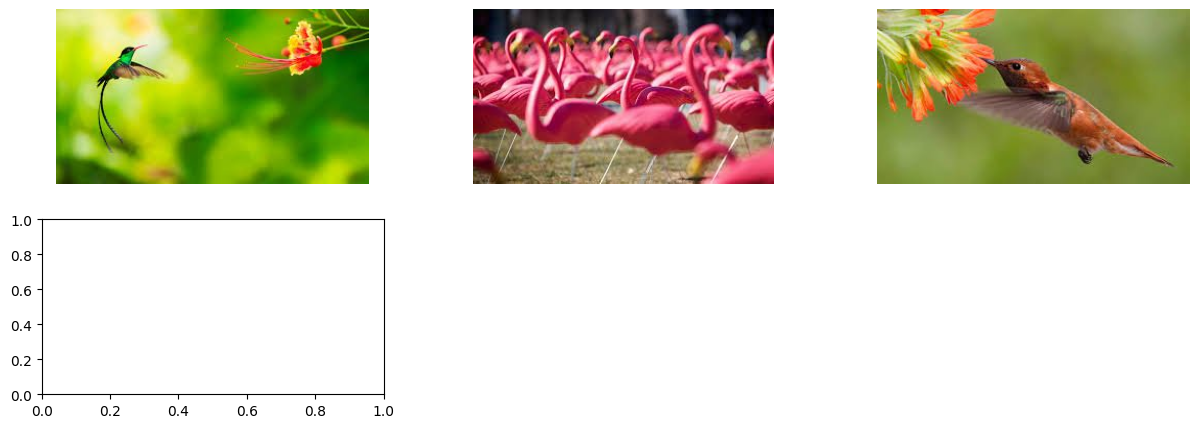

In [84]:
plt.figure(figsize=(15, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    img = Image.open(result[i])
    plt.imshow(img)
    plt.axis("off")
        
        